## 1.1 Optimizacion con Optuna: calibracion y discriminacion (variacion al notebook 11)

El notebook 11 optimizaba Brier score (que penaliza calibracion + resolucion juntas) y los notebooks anteriores (07) miraban solo AUC. Aqui queremos optimizar una metrica que mejore la calibracion sin degradar la discriminacion.

- Cargar directamente los pickles preprocessor.pkl y filter.pkl (mismos artefactos que el notebook 11). No re-preprocesar ni re-filtrar.
- Optimizar dos modelos (hemos elegido LightGBM, CatBoost) con Optuna + TPE y aplicar las siguientes variaciones respecto al notebook 11:

    - Metrica objetivo: usar una metrica que capture ambas dimensiones. Hemos elegido la metrica Log Loss la cual penaliza tanto la mala discriminacion como la mala calibracion.
    - Sampler/pruner: Hemos utilizado HyperbandPruner en lugar de MedianPruner
    - Cambiar n_startup_trials TPESampler. Hemos reducido el numero de startup trials de 10 a 5. Este parametro es el que controla cuántos trials iniciales hace Optuna de forma más aleatoria antes de empezar a usar TPE de verdad.Por lo tanto al reducir este valor, Optuna empieza antes a aprovechar la información de los primeros ensayos. Esto puede mejorar la optimización porque dedica menos tiempo a la exploracion aleatiria y prioriza buscar cerca de combinaciones prometedoras de hiperparámetros.
    - Espacio de busqueda: anadir o ampliar al menos un hiperparametro respecto al notebook 11 (feature_fraction_bynode en LightGBM, border_count en CatBoost).
    Hemos añadido en LightGBM el hiperparametro feature_fraction_bynode. Controla el porcentaje de variables que LightGBM puede considerar en cada nodo del árbol al buscar el mejor split. Es especialmente util para reducir el overfitting. 
    - Comparacion balanceado vs no balanceado: tanto el modelo de LightGBM como el modelo de CatBoost se han tratado con y sin balanceado. 
    - Comparar el best_value (la metrica elegida) y, sobre todo, las metricas finales en test. Comentar que opcion gana en calibracion (Brier/ECE) y que ocurre con discriminacion (AUC/MCC). Importante: el balanceo de clases sesga las probabilidades; comentar el efecto sobre la calibracion.
    - Para cada modelo final, calcular en test y mostrar en una tabla: Accuracy, Precision, Recall, F1, MCC, ROC-AUC, PR-AUC, Log Loss, Brier, ECE.
    
- Eleccion del modelo ganador que pasa a la siguiente fase, justificada por la metrica elegida.

In [1]:
import pickle
import numpy as np

with open("data/preprocessor.pkl", "rb") as f:
    preprocessor = pickle.load(f)

with open("data/filter.pkl", "rb") as f:
    feature_filter = pickle.load(f)


c:\Users\lalda\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\lalda\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator PolynomialFeatures from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\lalda\anaconda3\Lib\site-packages\sklearn\base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#sec

Metrica objetivo: usar una metrica que capture ambas dimensiones. Elegir una de las siguientes opciones (justificar la eleccion):
Log Loss (sklearn.metrics.log_loss): proper scoring rule, descomponible en resolution + reliability. Penaliza tanto la mala discriminacion como la mala calibracion. Es la opcion mas sencilla y la recomendada por defecto.

In [ ]:
with open('data/filtered/X_train_filtered.pkl', 'rb') as f:
    X_train_filtered = pickle.load(f)
with open('data/filtered/y_train_filtered.pkl', 'rb') as f:
    y_train = pickle.load(f)
with open('data/filtered/X_test_filtered.pkl', 'rb') as f:
    X_test_filtered = pickle.load(f)
with open('data/filtered/y_test_filtered.pkl', 'rb') as f:
    y_test = pickle.load(f)

y_train_flat = y_train.values.ravel()
y_test_flat = y_test.values.ravel()

n_negative = np.sum(~y_train_flat)
n_positive = np.sum(y_train_flat)
scale_pos_weight = n_negative / n_positive

print(f"Train: {X_train_filtered.shape}  |  Test: {X_test_filtered.shape}")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

Train: (80000, 163)  |  Test: (20000, 163)
scale_pos_weight = 3.93


In [3]:
# Split interno train/val para la optimizacion con TPE.
# El test queda reservado SOLO para la evaluacion final de los modelos tuneados.
# Si usaramos test en la optimizacion, las metricas finales estarian sesgadas (leakage).
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_filtered, y_train_flat,
    test_size=0.2, random_state=42, stratify=y_train_flat
)
print(f"Train interno: {X_tr.shape}  |  Val interno: {X_val.shape}")

Train interno: (64000, 163)  |  Val interno: (16000, 163)


In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, roc_auc_score,
    brier_score_loss, log_loss,matthews_corrcoef, average_precision_score
)
import matplotlib.pyplot as plt

def evaluate_model(model, X_test, y_test, model_name, results_dict):
    class_pred = model.predict(X_test)
    prob_pred = model.predict_proba(X_test)[:, 1]

    results_dict[model_name] = {
        'Accuracy': accuracy_score(y_test, class_pred),
        'Precision': precision_score(y_test, class_pred),
        'Recall': recall_score(y_test, class_pred),
        'F1-Score': f1_score(y_test, class_pred),
        "MCC": matthews_corrcoef(y_test, class_pred),
        "ROC-AUC": roc_auc_score(y_test, prob_pred),
        "PR-AUC": average_precision_score(y_test, prob_pred),
        "Log Loss": log_loss(y_test, prob_pred),
        "Brier": brier_score_loss(y_test, prob_pred),
        #"ECE": expected_calibration_error(y_test, prob_pred),
        'prob_pred': prob_pred,
        'class_pred': class_pred
    }

    print(f"\n{'='*60}\n  {model_name}\n{'='*60}")
    print(classification_report(y_test, class_pred, target_names=["Fully Paid", "Default"]))
    print(f"  Accuracy:  {results_dict[model_name]['Accuracy']:.4f}")
    print(f"  Precision: {results_dict[model_name]['Precision']:.4f}")
    print(f"  Recall:    {results_dict[model_name]['Recall']:.4f}")
    print(f"  F1-Score:  {results_dict[model_name]['F1-Score']:.4f}")
    print(f"  MCC:       {results_dict[model_name]['MCC']:.4f}")
    print(f"  ROC-AUC:   {results_dict[model_name]['ROC-AUC']:.4f}")
    print(f"  PR-AUC:    {results_dict[model_name]['PR-AUC']:.4f}")
    print(f"  Brier:     {results_dict[model_name]['Brier']:.4f}")
    print(f"  Log Loss:  {results_dict[model_name]['Log Loss']:.4f}")

    return results_dict

results = {}

# LIGHT_GBMP con balanceado

Añadimos el parametro feature_fraction_bynode. Controla el porcentaje de variables que el modelo puede usar en CADA split del árbol. 
El parámetro feature_fraction_bynode en LightGBM controla el porcentaje de variables disponibles en cada nodo del árbol. Cuando se incrementa su valor (cercano a 1), el modelo puede usar más variables en cada split, lo que aumenta su capacidad para encontrar divisiones óptimas y mejora la discriminación (por ejemplo, el AUC), pero también incrementa el riesgo de sobreajuste y puede empeorar la calibración al producir probabilidades más extremas. Por el contrario, al reducir este parámetro, el modelo utiliza menos variables en cada nodo, introduciendo regularización y mayor diversidad entre árboles, lo que suele mejorar la generalización y la calibración de las probabilidades (mejor Log Loss o Brier), aunque puede implicar una ligera pérdida de capacidad discriminativa si se descartan variables relevantes.

In [ ]:
import optuna
from optuna.integration import LightGBMPruningCallback
from lightgbm import LGBMClassifier
import lightgbm as lgb
from scipy.special import expit


def logloss_eval_lgbm(y_true, y_pred):
    y_pred = np.asarray(y_pred, dtype=float)

    if y_pred.min() < 0.0 or y_pred.max() > 1.0:
        y_pred = expit(y_pred)

    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)

    return 'logloss', log_loss(y_true, y_pred), False

def objective_lgbm(trial: optuna.Trial) -> float:
    params = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.5),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
        'feature_fraction_bynode': trial.suggest_float('feature_fraction_bynode', 0.6, 1.0)
    }

    model = LGBMClassifier(**params)

    pruning_cb = LightGBMPruningCallback(
        trial,
        metric='logloss',
        valid_name='valid_0'
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric=logloss_eval_lgbm,
        callbacks=[lgb.early_stopping(50, verbose=False), pruning_cb]
    )

    prob_val = model.predict_proba(X_val)[:, 1]
    return log_loss(y_val, prob_val)

In [6]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)

sampler = TPESampler(
    n_startup_trials=5,     # menos warmup → antes empieza TPE
    multivariate=True,
    seed=42,
)

pruner = HyperbandPruner(
    min_resource=50,        # equivalente a warmup (iteraciones mínimas)
    max_resource=1000,      # n_estimators máximo
    reduction_factor=3      # agresividad del pruning
)

study_lgbm = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    pruner=pruner,
    study_name='lightgbm_tpe_logloss',   # cambia también el nombre
)

study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print(f"\nMejor Log Loss en val: {study_lgbm.best_value:.4f}")
print(f"Mejores hiperparametros:")
for k, v in study_lgbm.best_params.items():
    print(f"  {k}: {v}")

c:\Users\lalda\anaconda3\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  0%|          | 0/50 [00:00<?, ?it/s]


Mejor Log Loss en val: 0.4967
Mejores hiperparametros:
  learning_rate: 0.051149244235341174
  num_leaves: 163
  max_depth: 11
  min_child_samples: 55
  subsample: 0.7190802458620112
  colsample_bytree: 0.5259554289831566
  reg_alpha: 3.3849889231649706e-07
  reg_lambda: 9.892155454912901
  min_split_gain: 0.3616274851775168
  feature_fraction_bynode: 0.7141215734159627


In [7]:
# Resumen del study: cuantos trials completados, pruned, etc.
states = [t.state.name for t in study_lgbm.trials]
from collections import Counter
print("Estados de los trials:", Counter(states))
print(f"Total trials: {len(study_lgbm.trials)}")

Estados de los trials: Counter({'PRUNED': 33, 'COMPLETE': 17})
Total trials: 50


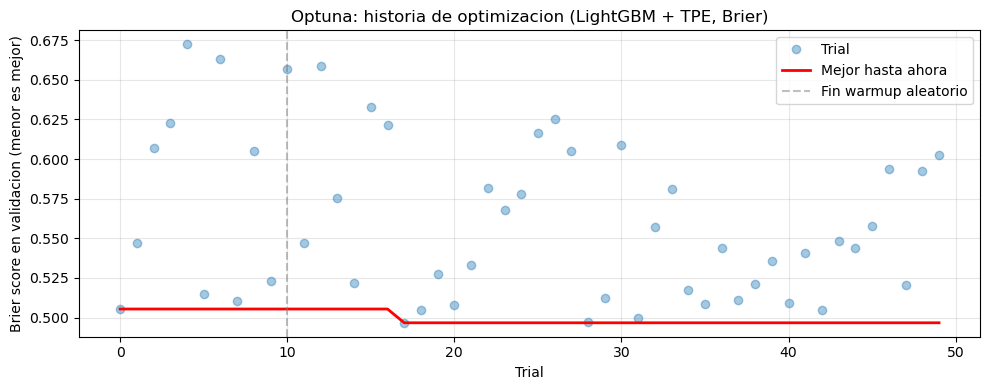

In [ ]:
# Historia de optimizacion: como baja el mejor Log Loss a medida que avanzan los trials.
# Con minimizacion la linea "mejor hasta ahora" baja escalonadamente (TPE enfoca en zonas buenas).
fig, ax = plt.subplots(figsize=(10, 4))
values = [t.value for t in study_lgbm.trials if t.value is not None]
best_so_far = np.minimum.accumulate(values)
ax.plot(range(len(values)), values, 'o', alpha=0.4, label='Trial')
ax.plot(range(len(best_so_far)), best_so_far, '-', lw=2, color='red', label='Mejor hasta ahora')
ax.axvline(10, color='gray', ls='--', alpha=0.5, label='Fin warmup aleatorio')
ax.set_xlabel('Trial')
ax.set_ylabel('Log Loss en validacion (menor es mejor)')
ax.set_title('Optuna: historia de optimizacion (LightGBM + TPE, Log Loss)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

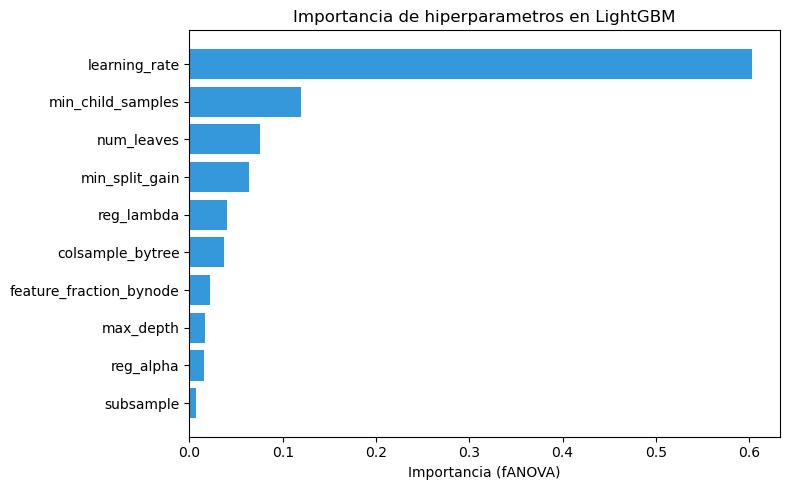

Ranking de importancia:
  learning_rate             0.603
  min_child_samples         0.119
  num_leaves                0.075
  min_split_gain            0.064
  reg_lambda                0.040
  colsample_bytree          0.037
  feature_fraction_bynode   0.022
  max_depth                 0.017
  reg_alpha                 0.015
  subsample                 0.007


In [9]:
# Importancia de hiperparametros segun Optuna (funcional ANOVA):
# que parametros explican mas la variabilidad del AUC entre trials?
importances = optuna.importance.get_param_importances(study_lgbm)

fig, ax = plt.subplots(figsize=(8, 5))
params_sorted = list(importances.keys())[::-1]
values_sorted = [importances[p] for p in params_sorted]
ax.barh(params_sorted, values_sorted, color='#3498db')
ax.set_xlabel('Importancia (fANOVA)')
ax.set_title('Importancia de hiperparametros en LightGBM')
plt.tight_layout()
plt.show()

print("Ranking de importancia:")
for p, v in importances.items():
    print(f"  {p:25s} {v:.3f}")

In [13]:
# Entrenamos el LightGBM final con los mejores hiperparametros y early stopping for log loss.
best_params_lgbm = dict(study_lgbm.best_params)
best_params_lgbm.update({
    'n_estimators': 2000,
    'subsample_freq': 1,
    'class_weight': 'balanced',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
})

lgbm_best = LGBMClassifier(**best_params_lgbm)
lgbm_best.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric=logloss_eval_lgbm,
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)
print(f"Iteraciones usadas tras early stopping: {lgbm_best.best_iteration_}")

results = evaluate_model(lgbm_best, X_test_filtered, y_test_flat, 'LightGBM + TPE', results)

Iteraciones usadas tras early stopping: 963

  LightGBM + TPE
              precision    recall  f1-score   support

  Fully Paid       0.83      0.90      0.86     16003
     Default       0.41      0.28      0.33      3997

    accuracy                           0.77     20000
   macro avg       0.62      0.59      0.60     20000
weighted avg       0.75      0.77      0.76     20000

  Accuracy:  0.7738
  Precision: 0.4051
  Recall:    0.2815
  F1-Score:  0.3322
  MCC:       0.2061
  ROC-AUC:   0.6844
  PR-AUC:    0.3500
  Brier:     0.1614
  Log Loss:  0.4973


# LIGHT_GBMP sin balanceado

In [ ]:

def logloss_eval_lgbm(y_true, y_pred):
    y_pred = np.asarray(y_pred, dtype=float)

    if y_pred.min() < 0.0 or y_pred.max() > 1.0:
        y_pred = expit(y_pred)

    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)

    return 'logloss', log_loss(y_true, y_pred), False

def objective_lgbm_nocw(trial: optuna.Trial) -> float:
    params = {
        'n_estimators': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 255),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.5),
        'class_weight': None,
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
        'feature_fraction_bynode': trial.suggest_float('feature_fraction_bynode', 0.6, 1.0)
    }

    model = LGBMClassifier(**params)

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric=logloss_eval_lgbm,
        callbacks=[lgb.early_stopping(50, verbose=False), pruning_cb]
    )

    prob_val = model.predict_proba(X_val)[:, 1]
    return log_loss(y_val, prob_val)

In [ ]:


optuna.logging.set_verbosity(optuna.logging.WARNING)

sampler = TPESampler(
    n_startup_trials=5,     # menos warmup → antes empieza TPE
    multivariate=True,
    seed=42,
)

pruner = HyperbandPruner(
    min_resource=50,        # equivalente a warmup (iteraciones mínimas)
    max_resource=1000,      # n_estimators máximo
    reduction_factor=3      # agresividad del pruning
)

study_lgbm = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    pruner=pruner,
    study_name='lightgbm_tpe_logloss',
)

study_lgbm.optimize(objective_lgbm_nocw, n_trials=50, show_progress_bar=True)

print(f"\nMejor Log Loss en val: {study_lgbm.best_value:.4f}")
print(f"Mejores hiperparametros:")
for k, v in study_lgbm.best_params.items():
    print(f"  {k}: {v}")

c:\Users\lalda\anaconda3\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  0%|          | 0/50 [00:00<?, ?it/s]


Mejor Log Loss en val: 0.4599
Mejores hiperparametros:
  learning_rate: 0.008780733396937534
  num_leaves: 168
  max_depth: 9
  min_child_samples: 52
  subsample: 0.5455651170768652
  colsample_bytree: 0.6152167217644856
  reg_alpha: 5.04417762013072e-06
  reg_lambda: 5.232438335749476
  min_split_gain: 0.2548128124006784
  feature_fraction_bynode: 0.6593049072717527


In [16]:
# Resumen del study: cuantos trials completados, pruned, etc.
states = [t.state.name for t in study_lgbm.trials]
from collections import Counter
print("Estados de los trials:", Counter(states))
print(f"Total trials: {len(study_lgbm.trials)}")

Estados de los trials: Counter({'PRUNED': 34, 'COMPLETE': 16})
Total trials: 50


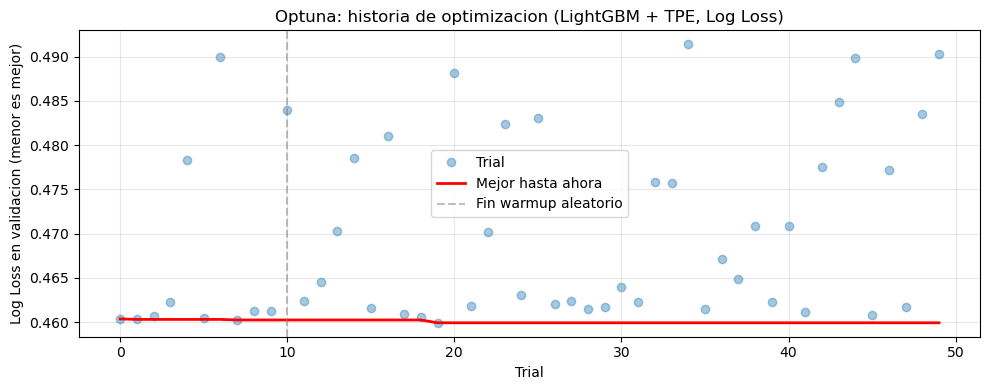

In [17]:
# Historia de optimizacion: como baja el mejor Log Loss a medida que avanzan los trials.
# Con minimizacion la linea "mejor hasta ahora" baja escalonadamente (TPE enfoca en zonas buenas).
fig, ax = plt.subplots(figsize=(10, 4))
values = [t.value for t in study_lgbm.trials if t.value is not None]
best_so_far = np.minimum.accumulate(values)
ax.plot(range(len(values)), values, 'o', alpha=0.4, label='Trial')
ax.plot(range(len(best_so_far)), best_so_far, '-', lw=2, color='red', label='Mejor hasta ahora')
ax.axvline(10, color='gray', ls='--', alpha=0.5, label='Fin warmup aleatorio')
ax.set_xlabel('Trial')
ax.set_ylabel('Log Loss en validacion (menor es mejor)')
ax.set_title('Optuna: historia de optimizacion (LightGBM + TPE, Log Loss)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

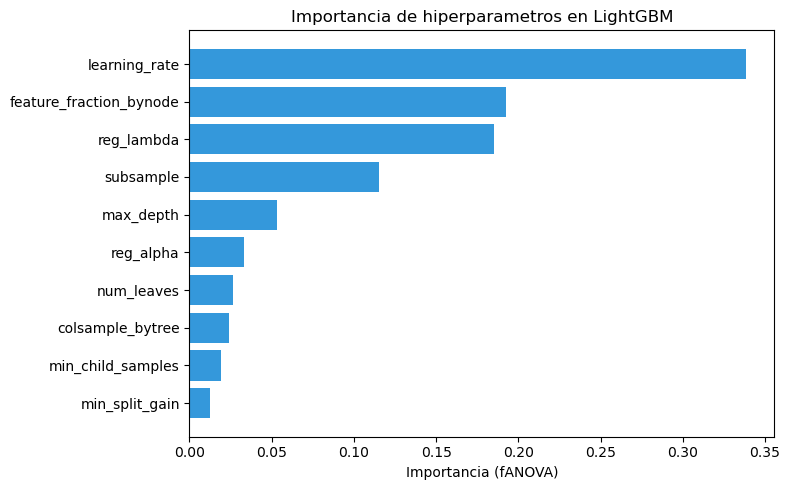

Ranking de importancia:
  learning_rate             0.339
  feature_fraction_bynode   0.192
  reg_lambda                0.185
  subsample                 0.115
  max_depth                 0.053
  reg_alpha                 0.033
  num_leaves                0.027
  colsample_bytree          0.024
  min_child_samples         0.019
  min_split_gain            0.012


In [18]:
# Importancia de hiperparametros segun Optuna (funcional ANOVA):
# que parametros explican mas la variabilidad del AUC entre trials?
importances = optuna.importance.get_param_importances(study_lgbm)

fig, ax = plt.subplots(figsize=(8, 5))
params_sorted = list(importances.keys())[::-1]
values_sorted = [importances[p] for p in params_sorted]
ax.barh(params_sorted, values_sorted, color='#3498db')
ax.set_xlabel('Importancia (fANOVA)')
ax.set_title('Importancia de hiperparametros en LightGBM')
plt.tight_layout()
plt.show()

print("Ranking de importancia:")
for p, v in importances.items():
    print(f"  {p:25s} {v:.3f}")

In [19]:
# Entrenamos el LightGBM final con los mejores hiperparametros y early stopping for log loss.
best_params_lgbm = dict(study_lgbm.best_params)
best_params_lgbm.update({
    'n_estimators': 2000,
    'subsample_freq': 1,
    'class_weight': None,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
})

lgbm_best = LGBMClassifier(**best_params_lgbm)
lgbm_best.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric=logloss_eval_lgbm,
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)
print(f"Iteraciones usadas tras early stopping: {lgbm_best.best_iteration_}")

results = evaluate_model(lgbm_best, X_test_filtered, y_test_flat, 'LightGBM + TPE', results)

Iteraciones usadas tras early stopping: 771

  LightGBM + TPE
              precision    recall  f1-score   support

  Fully Paid       0.81      0.99      0.89     16003
     Default       0.56      0.07      0.13      3997

    accuracy                           0.80     20000
   macro avg       0.68      0.53      0.51     20000
weighted avg       0.76      0.80      0.74     20000

  Accuracy:  0.8032
  Precision: 0.5585
  Recall:    0.0728
  F1-Score:  0.1288
  MCC:       0.1467
  ROC-AUC:   0.7084
  PR-AUC:    0.3775
  Brier:     0.1452
  Log Loss:  0.4552


# Cat_boost con balanceado

In [20]:
from catboost import CatBoostClassifier
from optuna.integration import CatBoostPruningCallback

def objective_catboost(trial: optuna.Trial) -> float:
    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'border_count': trial.suggest_categorical(
            'border_count',
            [32, 64, 128, 254]
        ),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
        'bootstrap_type': 'Bernoulli',
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'auto_class_weights': 'Balanced',

        'eval_metric': 'Logloss',
        'random_seed': 42,
        'early_stopping_rounds': 50,
        'verbose': False,
        'border_count': trial.suggest_categorical('border_count',[32, 64, 128, 254])
    }

    model = CatBoostClassifier(**params)

    pruning_cb = CatBoostPruningCallback(trial, 'Logloss')

    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        callbacks=[pruning_cb],
    )

    pruning_cb.check_pruned()

    prob_val = model.predict_proba(X_val)[:, 1]

    # Minimizar Log Loss
    return log_loss(y_val, prob_val)

In [21]:
from optuna.pruners import HyperbandPruner

study_catboost = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(n_startup_trials=10, multivariate=True, seed=42),
    pruner=HyperbandPruner(min_resource=50,max_resource=1000,reduction_factor=3),
    study_name='catboost_tpe_logloss',
)

study_catboost.optimize(objective_catboost, n_trials=40, show_progress_bar=True)

print(f"\nMejor Log Loss en val: {study_catboost.best_value:.4f}")
print("Mejores hiperparametros:")
for k, v in study_catboost.best_params.items():
    print(f"  {k}: {v}")

states = [t.state.name for t in study_catboost.trials]
print(f"\nEstados de los trials: {Counter(states)}")

c:\Users\lalda\anaconda3\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  0%|          | 0/40 [00:00<?, ?it/s]

C:\Users\lalda\AppData\Local\Temp\ipykernel_27832\2766813534.py:30: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'Logloss')
C:\Users\lalda\AppData\Local\Temp\ipykernel_27832\2766813534.py:30: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'Logloss')
C:\Users\lalda\AppData\Local\Temp\ipykernel_27832\2766813534.py:30: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'Logloss')
C:\Users\lalda\AppData\Local\Temp\ipykernel_27832\2766813534.py:30: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'Loglos


Mejor Log Loss en val: 0.5960
Mejores hiperparametros:
  learning_rate: 0.032944010561432216
  depth: 10
  border_count: 128
  l2_leaf_reg: 4.004478941512081
  min_data_in_leaf: 54
  subsample: 0.6936317144644276
  colsample_bylevel: 0.9026105610699617
  random_strength: 0.06611200677142658

Estados de los trials: Counter({'COMPLETE': 24, 'PRUNED': 16})


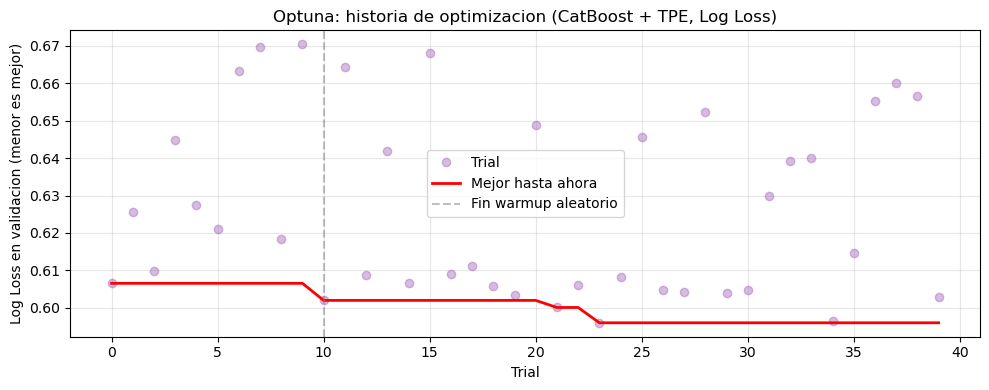


Ranking de importancia (CatBoost):
  learning_rate             0.732
  random_strength           0.081
  colsample_bylevel         0.050
  depth                     0.044
  l2_leaf_reg               0.033
  min_data_in_leaf          0.028
  border_count              0.023
  subsample                 0.008


In [22]:
# Historia de optimizacion + importancia para CatBoost
fig, ax = plt.subplots(figsize=(10, 4))
values = [t.value for t in study_catboost.trials if t.value is not None]
best_so_far = np.minimum.accumulate(values)
ax.plot(range(len(values)), values, 'o', alpha=0.4, color='#9b59b6', label='Trial')
ax.plot(range(len(best_so_far)), best_so_far, '-', lw=2, color='red', label='Mejor hasta ahora')
ax.axvline(10, color='gray', ls='--', alpha=0.5, label='Fin warmup aleatorio')
ax.set_xlabel('Trial')
ax.set_ylabel('Log Loss en validacion (menor es mejor)')
ax.set_title('Optuna: historia de optimizacion (CatBoost + TPE, Log Loss)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

importances_cb = optuna.importance.get_param_importances(study_catboost)
print("\nRanking de importancia (CatBoost):")
for p, v in importances_cb.items():
    print(f"  {p:25s} {v:.3f}")

In [23]:
# CatBoost final con mejores params
best_params_cb = dict(study_catboost.best_params)
best_params_cb.update({
    'iterations': 2000,
    'bootstrap_type': 'Bernoulli',
    'auto_class_weights': 'Balanced',
    'eval_metric': 'Logloss',
    'random_seed': 42,
    'early_stopping_rounds': 50,
    'verbose': False,
})

catboost_best = CatBoostClassifier(**best_params_cb)
catboost_best.fit(X_tr, y_tr, eval_set=(X_val, y_val))
print(f"Iteraciones usadas tras early stopping: {catboost_best.get_best_iteration()}")

results = evaluate_model(catboost_best, X_test_filtered, y_test_flat, 'CatBoost + TPE', results)

Iteraciones usadas tras early stopping: 157

  CatBoost + TPE
              precision    recall  f1-score   support

  Fully Paid       0.87      0.70      0.78     16003
     Default       0.33      0.58      0.42      3997

    accuracy                           0.68     20000
   macro avg       0.60      0.64      0.60     20000
weighted avg       0.76      0.68      0.71     20000

  Accuracy:  0.6803
  Precision: 0.3298
  Recall:    0.5812
  F1-Score:  0.4208
  MCC:       0.2396
  ROC-AUC:   0.7035
  PR-AUC:    0.3716
  Brier:     0.2045
  Log Loss:  0.5952


# Cat_Boost sin balanceado

In [24]:
from catboost import CatBoostClassifier
from optuna.integration import CatBoostPruningCallback

def objective_catboost_sb(trial: optuna.Trial) -> float:
    params = {
        'iterations': 1000,
        'learning_rate': trial.suggest_float('learning_rate', 5e-3, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'border_count': trial.suggest_categorical(
            'border_count',
            [32, 64, 128, 254]
        ),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
        'bootstrap_type': 'Bernoulli',
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),

        'eval_metric': 'Logloss',
        'random_seed': 42,
        'early_stopping_rounds': 50,
        'verbose': False,
        'border_count': trial.suggest_categorical('border_count',[32, 64, 128, 254])
    }

    model = CatBoostClassifier(**params)

    pruning_cb = CatBoostPruningCallback(trial, 'Logloss')

    model.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        callbacks=[pruning_cb],
    )

    pruning_cb.check_pruned()

    prob_val = model.predict_proba(X_val)[:, 1]

    # Minimizar Log Loss
    return log_loss(y_val, prob_val)

In [25]:
from optuna.pruners import HyperbandPruner

study_catboost = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(n_startup_trials=10, multivariate=True, seed=42),
    pruner=HyperbandPruner(min_resource=50,max_resource=1000,reduction_factor=3),
    study_name='catboost_tpe_logloss',
)

study_catboost.optimize(objective_catboost_sb, n_trials=40, show_progress_bar=True)

print(f"\nMejor Log Loss en val: {study_catboost.best_value:.4f}")
print("Mejores hiperparametros:")
for k, v in study_catboost.best_params.items():
    print(f"  {k}: {v}")

states = [t.state.name for t in study_catboost.trials]
print(f"\nEstados de los trials: {Counter(states)}")

c:\Users\lalda\anaconda3\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


  0%|          | 0/40 [00:00<?, ?it/s]

C:\Users\lalda\AppData\Local\Temp\ipykernel_27832\3113755220.py:29: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'Logloss')
C:\Users\lalda\AppData\Local\Temp\ipykernel_27832\3113755220.py:29: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'Logloss')
C:\Users\lalda\AppData\Local\Temp\ipykernel_27832\3113755220.py:29: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'Logloss')
C:\Users\lalda\AppData\Local\Temp\ipykernel_27832\3113755220.py:29: ExperimentalWarning: CatBoostPruningCallback is experimental (supported from v3.0.0). The interface can change in the future.
  pruning_cb = CatBoostPruningCallback(trial, 'Loglos


Mejor Log Loss en val: 0.4591
Mejores hiperparametros:
  learning_rate: 0.08933495700469019
  depth: 4
  border_count: 64
  l2_leaf_reg: 6.177879947449825
  min_data_in_leaf: 6
  subsample: 0.8709325673609113
  colsample_bylevel: 0.5890207293696058
  random_strength: 0.018356030648672236

Estados de los trials: Counter({'PRUNED': 23, 'COMPLETE': 17})


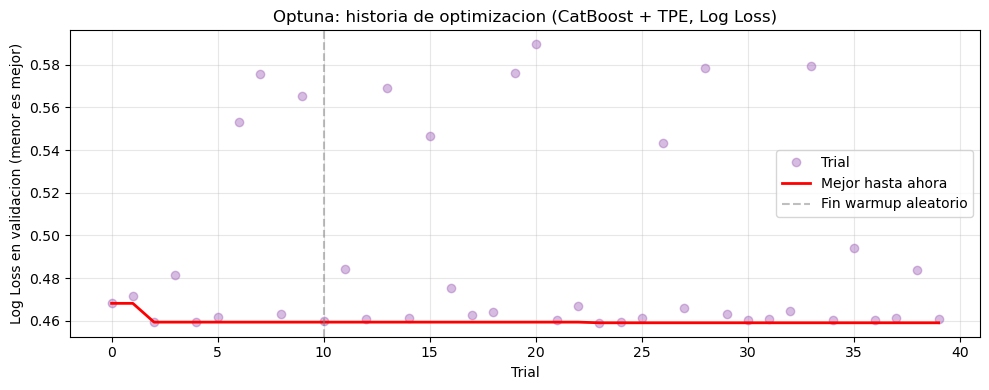


Ranking de importancia (CatBoost):
  depth                     0.442
  learning_rate             0.152
  random_strength           0.149
  subsample                 0.098
  l2_leaf_reg               0.062
  colsample_bylevel         0.039
  border_count              0.035
  min_data_in_leaf          0.023


In [26]:
# Historia de optimizacion + importancia para CatBoost
fig, ax = plt.subplots(figsize=(10, 4))
values = [t.value for t in study_catboost.trials if t.value is not None]
best_so_far = np.minimum.accumulate(values)
ax.plot(range(len(values)), values, 'o', alpha=0.4, color='#9b59b6', label='Trial')
ax.plot(range(len(best_so_far)), best_so_far, '-', lw=2, color='red', label='Mejor hasta ahora')
ax.axvline(10, color='gray', ls='--', alpha=0.5, label='Fin warmup aleatorio')
ax.set_xlabel('Trial')
ax.set_ylabel('Log Loss en validacion (menor es mejor)')
ax.set_title('Optuna: historia de optimizacion (CatBoost + TPE, Log Loss)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

importances_cb = optuna.importance.get_param_importances(study_catboost)
print("\nRanking de importancia (CatBoost):")
for p, v in importances_cb.items():
    print(f"  {p:25s} {v:.3f}")

In [27]:
# CatBoost final con mejores params
best_params_cb = dict(study_catboost.best_params)
best_params_cb.update({
    'iterations': 2000,
    'bootstrap_type': 'Bernoulli',
    'auto_class_weights': None,
    'eval_metric': 'Logloss',
    'random_seed': 42,
    'early_stopping_rounds': 50,
    'verbose': False,
})

catboost_best = CatBoostClassifier(**best_params_cb)
catboost_best.fit(X_tr, y_tr, eval_set=(X_val, y_val))
print(f"Iteraciones usadas tras early stopping: {catboost_best.get_best_iteration()}")

results = evaluate_model(catboost_best, X_test_filtered, y_test_flat, 'CatBoost + TPE', results)

Iteraciones usadas tras early stopping: 497

  CatBoost + TPE
              precision    recall  f1-score   support

  Fully Paid       0.81      0.98      0.89     16003
     Default       0.53      0.09      0.15      3997

    accuracy                           0.80     20000
   macro avg       0.67      0.53      0.52     20000
weighted avg       0.76      0.80      0.74     20000

  Accuracy:  0.8021
  Precision: 0.5304
  Recall:    0.0851
  F1-Score:  0.1466
  MCC:       0.1504
  ROC-AUC:   0.7054
  PR-AUC:    0.3729
  Brier:     0.1457
  Log Loss:  0.4567


## COMPARACION DE MODELOS Y ELECCION DEL MEJOR MODELO
La siguiente tabla presenta a modo resumen los resultados de las metricas estudiadas para cada combiandacion de los dos modelos estudiados con y sin balanceo. 
| Modelo | Accuracy | Precision (Default) | Recall (Default) | F1-score (Default) | MCC | ROC-AUC | PR-AUC | Brier | Log Loss |
|---|---|---|---|---|---|---|---|---|---|
| **LightGBM + Balanceado** | 0.8021 | 0.53 | 0.09 | 0.15 | 0.1504 | 0.7054 | 0.3729 | 0.1457 | 0.4567 |
| **LightGBM + Sin balanceado** | 0.8032 | 0.56 | 0.07 | 0.13 | 0.1467 | 0.7084 | 0.3775 | 0.1452 | 0.4552 |
| **CatBoost + Balanceado** | 0.6803 | 0.33 | 0.58 | 0.42 | 0.2396 | 0.7035 | 0.3716 | 0.2045 | 0.5952 |
| **CatBoost + Sin balanceado** | 0.8021 | 0.53 | 0.09 | 0.15 | 0.1504 | 0.7054 | 0.3729 | 0.1457 | 0.4567 |

Comparamos los modelos, basandonos especialmente en el valor del parametro Log Loss. El Log Loss es una métrica de evaluación que cuantifica la discrepancia entre las probabilidades predichas por un modelo y las clases reales observadas.Un valor de Log Loss cercano a 0 indica que el modelo asigna altas probabilidades a las clases correctas, por el otro lado, valores más elevados reflejan una peor calibración probabilística y una mayor incertidumbre o error en las predicciones.

Por lo tanto, elegimos como mejor modelo LightGBM sin balanceado. Además del menor valor de Log loss presenta el valor mas alto de ROC-AUC lo que implica una mayor capacidad para distinguir entre clientes que han pagado y clientes que han hecho default. Asimismo, tiene ha obtenido tambien la tasa de "accuracy" más alta, es decir, el porcentaje mas alto de aciertos en los que el modelo ha clasificado correctamnete tanto la clase positiva como la clase negativa.



## 1.2 Calibracion (variacion al notebook 10)
Decision: tomar de forma explicita la decision de calibrar o no, justificada con los numeros del diagnostico.
- Si se decide calibrar: aplicar un metodo fiable (sigmoid / isotonic u otro justificado) y verificar que la calibracion mejora (ECE, Brier) sin degradar la discriminacion (AUC, MCC).
- Si se decide NO calibrar: explicar por que el modelo no necesita calibracion, argumentado con datos.

In [28]:
#Para calibrar las probabilidades necesitamos **tres conjuntos** disjuntos:
#1. **Train** (60%): entrenar el modelo CatBoost
#2. **Validacion** (20%): early stopping durante el entrenamiento
#3. **Calibracion** (20%): ajustar los metodos de calibracion post-hoc

# Paso 1: separar calibracion (20%) del resto (80%)
X_train_rest, X_cal, y_train_rest, y_cal = train_test_split(
    X_train_filtered, y_train_flat, test_size=0.2, random_state=42, stratify=y_train_flat
)

# Paso 2: separar train (75% del resto = 60% original) y validacion (25% del resto = 20% original)
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_rest, y_train_rest, test_size=0.25, random_state=42, stratify=y_train_rest
)

print(f"Train:       {X_train_sub.shape}  ({len(X_train_sub)/len(X_train_filtered)*100:.0f}%)")
print(f"Validacion:  {X_val.shape}  ({len(X_val)/len(X_train_filtered)*100:.0f}%)")
print(f"Calibracion: {X_cal.shape}  ({len(X_cal)/len(X_train_filtered)*100:.0f}%)")
print(f"Test:        {X_test_filtered.shape}")

Train:       (48000, 163)  (60%)
Validacion:  (16000, 163)  (20%)
Calibracion: (16000, 163)  (20%)
Test:        (20000, 163)


In [37]:
best_params_lgbm.update({
    'n_estimators': 2000,
    'subsample_freq': 1,
    'class_weight': None,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
})

lgbm_sinbalanceado = LGBMClassifier(**best_params_lgbm)
lgbm_sinbalanceado.fit(
    X_train_sub, y_train_sub,
    eval_set=(X_val, y_val),
    eval_metric=logloss_eval_lgbm,
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)]
)

LGBMClassifier(colsample_bytree=0.6152167217644856,
               feature_fraction_bynode=0.6593049072717527,
               learning_rate=0.008780733396937534, max_depth=9,
               min_child_samples=52, min_split_gain=0.2548128124006784,
               n_estimators=2000, n_jobs=-1, num_leaves=168, random_state=42,
               reg_alpha=5.04417762013072e-06, reg_lambda=5.232438335749476,
               subsample=0.5455651170768652, subsample_freq=1, verbose=-1)

In [44]:
from sklearn.metrics import classification_report, roc_auc_score, brier_score_loss, log_loss

y_pred = lgbm_sinbalanceado.predict(X_test_filtered)
y_prob = lgbm_sinbalanceado.predict_proba(X_test_filtered)[:, 1]

print("Evaluacion de LightGBM sobre Test:")
print(classification_report(y_test_flat, y_pred, target_names=["Fully Paid", "Default"]))
print(f"AUC-ROC:     {roc_auc_score(y_test_flat, y_prob):.4f}")
print(f"Brier Score: {brier_score_loss(y_test_flat, y_prob):.4f}")
print(f"Log-Loss:    {log_loss(y_test_flat, y_prob):.4f}")

Evaluacion de LightGBM sobre Test:
              precision    recall  f1-score   support

  Fully Paid       0.81      0.99      0.89     16003
     Default       0.56      0.06      0.11      3997

    accuracy                           0.80     20000
   macro avg       0.68      0.52      0.50     20000
weighted avg       0.76      0.80      0.73     20000

AUC-ROC:     0.7069
Brier Score: 0.1455
Log-Loss:    0.4561


### Analizamos si el modelo necesita calibración, calculando: 
- Curva de calibracion (inspeccion visual): La curva de calibracion (reliability diagram) agrupa las predicciones en bins y compara la probabilidad media predicha con la frecuencia observada de positivos. Una curva perfectamente calibrada sigue la diagonal.
- Descomposicion de Brier Score (Murphy): Separamos el Brier score en sus tres componentes para entender **donde** falla el modelo: en calibracion (reliability) o en discriminacion (resolution).
- Test de Spiegelhalter (test formal de calibracion): El test Z de Spiegelhalter compara el Brier score observado con su valor esperado
bajo la hipotesis nula de calibracion perfecta.
    - $H_0$: el modelo esta bien calibrado (las probabilidades predichas coinciden con las reales)
    - $H_1$: el modelo **no** esta bien calibrado
    - Criterio: rechazamos $H_0$ si $|Z| > 1.96$ (nivel de significacion 5%)

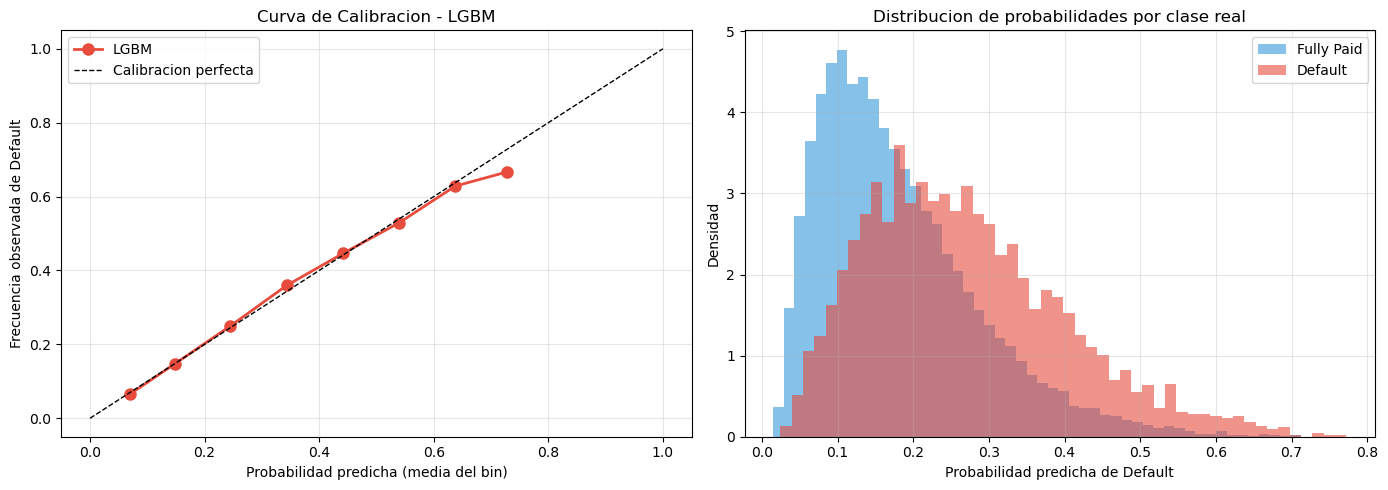

Detalle por bin:
    Bin  Prob predicha   Freq observada   Desviacion
  --------------------------------------------------
      1         0.0705           0.0662      +0.0043
      2         0.1477           0.1468      +0.0008
      3         0.2449           0.2497      -0.0048
      4         0.3432           0.3595      -0.0162
      5         0.4418           0.4463      -0.0045
      6         0.5395           0.5290      +0.0105
      7         0.6374           0.6283      +0.0091
      8         0.7279           0.6667      +0.0613


In [39]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva de calibracion
prob_true, prob_pred = calibration_curve(y_test_flat, y_prob, n_bins=10, strategy='uniform')

axes[0].plot(prob_pred, prob_true, 'o-', color='#e74c3c', lw=2, markersize=8, label='LGBM')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Calibracion perfecta')
axes[0].set_xlabel('Probabilidad predicha (media del bin)')
axes[0].set_ylabel('Frecuencia observada de Default')
axes[0].set_title('Curva de Calibracion - LGBM')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histograma de probabilidades predichas
axes[1].hist(y_prob[y_test_flat == 0], bins=50, alpha=0.6, label='Fully Paid', color='#3498db', density=True)
axes[1].hist(y_prob[y_test_flat == 1], bins=50, alpha=0.6, label='Default', color='#e74c3c', density=True)
axes[1].set_xlabel('Probabilidad predicha de Default')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribucion de probabilidades por clase real')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Desviaciones por bin
print("Detalle por bin:")
print(f"  {'Bin':>5} {'Prob predicha':>14} {'Freq observada':>16} {'Desviacion':>12}")
print(f"  {'-'*50}")
for i in range(len(prob_true)):
    dev = prob_pred[i] - prob_true[i]
    print(f"  {i+1:>5} {prob_pred[i]:>14.4f} {prob_true[i]:>16.4f} {dev:>+12.4f}")

In [40]:
def brier_decomposition(y_true, y_prob, n_bins=10):
    """
    Descomposicion de Murphy del Brier score:
    Brier = Reliability - Resolution + Uncertainty

    - Reliability (calibracion): menor es mejor (0 = perfecto)
    - Resolution (discriminacion): mayor es mejor
    - Uncertainty: constante del dataset
    """
    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_prob, bins) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)

    N = len(y_true)
    o_bar = y_true.mean()  # tasa base de positivos

    reliability = 0.0
    resolution = 0.0
    bin_details = []

    for k in range(n_bins):
        mask = bin_indices == k
        n_k = mask.sum()
        if n_k == 0:
            continue
        p_bar_k = y_prob[mask].mean()    # probabilidad media predicha en bin k
        o_bar_k = y_true[mask].mean()    # frecuencia observada en bin k

        reliability += n_k * (p_bar_k - o_bar_k) ** 2
        resolution += n_k * (o_bar_k - o_bar) ** 2

        bin_details.append({
            'bin': k + 1, 'n': n_k, 'p_pred': p_bar_k,
            'p_obs': o_bar_k, 'gap': abs(p_bar_k - o_bar_k)
        })

    reliability /= N
    resolution /= N
    uncertainty = o_bar * (1 - o_bar)
    brier_decomp = reliability - resolution + uncertainty

    return {
        'reliability': reliability,
        'resolution': resolution,
        'uncertainty': uncertainty,
        'brier_decomposed': brier_decomp,
        'brier_direct': np.mean((y_true - y_prob) ** 2),
        'bin_details': bin_details
    }


decomp = brier_decomposition(y_test_flat, y_prob)

print("=" * 60)
print("DESCOMPOSICION DE BRIER SCORE (Murphy)")
print("=" * 60)
print(f"\n  Brier Score (directo):          {decomp['brier_direct']:.6f}")
print(f"  Brier Score (descompuesto):     {decomp['brier_decomposed']:.6f}")
print(f"\n  Reliability (calibracion):      {decomp['reliability']:.6f}  (menor = mejor, 0 = perfecto)")
print(f"  Resolution  (discriminacion):   {decomp['resolution']:.6f}  (mayor = mejor)")
print(f"  Uncertainty (dato):             {decomp['uncertainty']:.6f}  (constante)")
print(f"\n  Ratio Reliability/Resolution:   {decomp['reliability']/decomp['resolution']:.4f}")

if decomp['reliability'] > decomp['resolution']:
    print("\n  >>> La reliability SUPERA la resolution: el modelo pierde mas")
    print("      por mala calibracion de lo que gana por buena discriminacion.")
else:
    print("\n  >>> La resolution supera la reliability: la discriminacion aporta")
    print("      mas de lo que la mala calibracion quita.")

DESCOMPOSICION DE BRIER SCORE (Murphy)

  Brier Score (directo):          0.145471
  Brier Score (descompuesto):     0.146225

  Reliability (calibracion):      0.000044  (menor = mejor, 0 = perfecto)
  Resolution  (discriminacion):   0.013729  (mayor = mejor)
  Uncertainty (dato):             0.159910  (constante)

  Ratio Reliability/Resolution:   0.0032

  >>> La resolution supera la reliability: la discriminacion aporta
      mas de lo que la mala calibracion quita.


In [43]:
def spiegelhalter_z_test(y_true, y_prob):
    """
    Test de Spiegelhalter (1986) para calibracion.

    H0: el modelo esta calibrado (p_i = P(Y=1|X=x_i))
    H1: el modelo NO esta calibrado

    Returns: Z-statistic, Brier observado, Brier esperado bajo H0
    """
    N = len(y_true)

    # Brier score observado
    B_obs = np.mean((y_true - y_prob) ** 2)

    # Brier esperado bajo calibracion perfecta
    B_exp = np.mean(y_prob * (1 - y_prob))

    # Varianza bajo H0
    Var_B = (1 / N**2) * np.sum((1 - 2 * y_prob)**2 * y_prob * (1 - y_prob))

    # Z-estadistico
    Z = (B_obs - B_exp) / np.sqrt(Var_B)

    return Z, B_obs, B_exp


Z_stat, B_obs, B_exp = spiegelhalter_z_test(y_test_flat, y_prob)
auc = roc_auc_score(y_test_flat, y_prob)

print("=" * 60)
print("TEST DE SPIEGELHALTER")
print("=" * 60)
print(f"\n  Brier observado:    {B_obs:.6f}")
print(f"  Brier esperado H0:  {B_exp:.6f}")
print(f"  Diferencia:         {B_obs - B_exp:.6f}")
print(f"\n  Z-estadistico:      {Z_stat:.4f}")
print(f"  Umbral (alpha=5%):  1.96")
print(f"  |Z| > 1.96?         {'SI' if abs(Z_stat) > 1.96 else 'NO'}")

if abs(Z_stat) > 1.96:
    print(f"\n  >>> RESULTADO: Rechazamos H0. Las probabilidades de LightGBM")
    print(f"      NO estan calibradas (|Z| = {abs(Z_stat):.2f} >> 1.96).")
    print(f"      El modelo NECESITA calibracion post-hoc.")
else:
    print(f"\n  >>> RESULTADO: No rechazamos H0. Las probabilidades de LightGBM")
    print(f"      estan razonablemente calibradas (|Z| = {abs(Z_stat):.2f} < 1.96).")

TEST DE SPIEGELHALTER

  Brier observado:    0.145471
  Brier esperado H0:  0.145293
  Diferencia:         0.000178

  Z-estadistico:      0.1161
  Umbral (alpha=5%):  1.96
  |Z| > 1.96?         NO

  >>> RESULTADO: No rechazamos H0. Las probabilidades de LightGBM
      estan razonablemente calibradas (|Z| = 0.12 < 1.96).


In [50]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Expected Calibration Error (ECE)."""
    bins = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_prob, bins) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)

    N = len(y_true)
    ece = 0.0
    for k in range(n_bins):
        mask = bin_indices == k
        n_k = mask.sum()
        if n_k == 0:
            continue
        avg_pred = y_prob[mask].mean()
        avg_true = y_true[mask].mean()
        ece += (n_k / N) * abs(avg_pred - avg_true)
    return ece


ece = expected_calibration_error(y_test_flat, y_prob)
print(f"Expected Calibration Error (ECE): {ece:.4f}")
print(f"\nInterpretacion: en promedio, las probabilidades predichas se desvian")
print(f"un {ece*100:.2f}% de la frecuencia real de default en cada bin.")

Expected Calibration Error (ECE): 0.0046

Interpretacion: en promedio, las probabilidades predichas se desvian
un 0.46% de la frecuencia real de default en cada bin.


In [51]:
print("=" * 60)
print("DIAGNOSTICO")
print("=" * 60)
print(f"\n  AUC-ROC:              {auc:.4f}")
print(f"  |Z| Spiegelhalter:    {abs(Z_stat):.4f}")
print(f"  ECE:                  {ece:.4f}")
print(f"  Reliability (Brier):  {decomp['reliability']:.6f}")

calibrado = abs(Z_stat) < 1.96
buena_discriminacion = auc > 0.65  # umbral razonable para riesgo de credito

print(f"\n  Discriminacion: {'BUENA' if buena_discriminacion else 'MALA'} (AUC = {auc:.4f})")
print(f"  Calibracion:    {'BUENA' if calibrado else 'MALA'} (|Z| = {abs(Z_stat):.2f})")

if buena_discriminacion and not calibrado:
    print(f"\n  >>> ACCION: Buena discriminacion + mala calibracion.")
    print(f"      Esta es la mejor situacion para calibrar post-hoc.")
    print(f"      La discriminacion (AUC) ya esta; solo falta corregir las probabilidades.")
    print(f"      Procedemos a comparar metodos de calibracion.")
elif buena_discriminacion and calibrado:
    print(f"\n  >>> ACCION: Buena discriminacion + buena calibracion.")
    print(f"      El modelo esta listo para usar. No necesita calibracion.")
    print(f"      Igualmente compararemos metodos para fines educativos.")
elif not buena_discriminacion and not calibrado:
    print(f"\n  >>> ACCION: Mala discriminacion + mala calibracion.")
    print(f"      Ningun calibrador post-hoc puede arreglar esto. Reentrenar.")
else:
    print(f"\n  >>> ACCION: Mala discriminacion + buena calibracion.")
    print(f"      Bien calibrado pero no discrimina. Practicamente inutil.")

DIAGNOSTICO

  AUC-ROC:              0.7069
  |Z| Spiegelhalter:    0.1161
  ECE:                  0.0046
  Reliability (Brier):  0.000044

  Discriminacion: BUENA (AUC = 0.7069)
  Calibracion:    BUENA (|Z| = 0.12)

  >>> ACCION: Buena discriminacion + buena calibracion.
      El modelo esta listo para usar. No necesita calibracion.
      Igualmente compararemos metodos para fines educativos.


# CONCLUSIONES DE CALIBRACIÓN

Tras el análisis de calibración realizado sobre el modelo LightLGB sin balanceado podemos concluir que las prabilidades que genera estan suficientemente calibradas y, por lo tanto, no es necesario aplicar una calibración adicional. 

Esta decision se toma en base a las siguientes conclusiones: 
- En primer lugar, como ya se ha comentado anteriormente, el modelo presenta resultados optimos al analizar las metricas principales (ROC AUC, Log Loss y Brier Score). 
- Ademas, si analizamos visualmente la curva de calibración, es muy similar a la bisectriz. 
- La descomposición del Brier Score también apoya esta idea. El componente de Reliability, que mide el error de calibración, es prácticamente cero, mientras que la Resolution es bastante mayor, lo que significa que el modelo discrimina mejor entre clientes de bajo y alto riesgo de lo que pierde por posibles errores de calibración.
- Por otro lado, analizando el ECE las probabilidades predichas se desvian solo un 0.46% de la frecuencia real de default en cada bin.
- Por ultimo, al realizar el test de Spiegelhalter el estadistico toma un valor de 0.12 que es muy inferior a 1.96. 

# 1.3 Medida de incertidumbre y derivación a un agente

Hasta aquí tenemos una probabilidad puntual \(p\) para cada cliente. Pero esa probabilidad puede ser, ella misma, incierta: dos clientes pueden tener \(p = 0.55\) y, sin embargo, en uno el modelo estar razonablemente seguro de que la probabilidad real esta cerca de 0.55 y en el otro no tiene ni idea (podria estar en cualquier sitio entre 0.4 y 0.7). Queremos detectar este segundo caso y derivar a un agente humano.

- Pregunta abierta a responder en el notebook: Tengo una probabilidad puntual de mi modelo. ¿Que necesito para medir la incertidumbre de esa probabilidad y poder derivar a un agente cuando esa incertidumbre sea alta? ¿Me sirve la calibracion clasica (sigmoid/isotonic)? ¿Que estoy obteniendo realmente con cada metodo?
- Argumentar la respuesta y elegir un metodo que permita obtener, para cada prediccion, un intervalo de probabilidad \([p_{low}, p_{high}]\) (la anchura de ese intervalo sera la medida de incertidumbre). Justificar la eleccion del metodo.

- Implementacion
Aplicar el metodo elegido al modelo final. Para cada sample de test obtener:
p_low
p_high


### Respuesta a la pregunta planteada

La calibracion mediante métodos como sigmoid o Isotonic Regression tiene como objetivo corregir las probabilidades que genera un modelo para que se parezcan mas a las probabilidades reales observadas.

- SIGMOID: 
Ajusta una funcion sigmoide sobre las probabilidades originales del modelo.
Principalmente, transforma las probabilidades mas extremas de forma que reduce las probabilidades muy altas aumenta las muy bajas. Se utiliza principalmnete con bases con pocos datos. 

- ISOTONIC REGRESION
No asume una forma concreta como ocurre con sigmoide sino que se adapta direcatmente las probabilidades predichas a las reales. Necesita bases con mas datos.  

Por tanto, no proporciona informacion sobre la incertidumbre individual de cada prediccion, sino que lo hacen de forma global. 

Para medir realmente la incertidumbre de cada prediccion se necesita un metodo que proporcione no solo una probabilidad puntual.El metodo que se utiliza es **Venn-Abers**. 


In [45]:
# Probabilidades del modelo base sobre calibracion y test
probs_cal = lgbm_sinbalanceado.predict_proba(X_cal)[:, 1]
probs_test = lgbm_sinbalanceado.predict_proba(X_test_filtered)[:, 1]

print(f"Probabilidades de calibracion: {probs_cal.shape}")
print(f"Probabilidades de test:        {probs_test.shape}")
print(f"\nRango de probabilidades en test: [{probs_test.min():.4f}, {probs_test.max():.4f}]")
print(f"Media de probabilidades en test:  {probs_test.mean():.4f}")
print(f"Tasa real de default en test:     {y_test_flat.mean():.4f}")

Probabilidades de calibracion: (16000,)
Probabilidades de test:        (20000,)

Rango de probabilidades en test: [0.0151, 0.7720]
Media de probabilidades en test:  0.1982
Tasa real de default en test:     0.1998


In [47]:
import sys
!{sys.executable} -m pip install venn-abers

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for venn-abers: filename=venn_abers-1.5.3-py3-none-any.whl size=15528 sha256=700a9cb32da769852c3896239f343aa8b23e0c15553dded3ef2b96760c60cb28
  Stored in directory: c:\users\lalda\appdata\local\pip\cache\wheels\09\d5\91\03fd870fd143201943dfeb0535b7dd4450aa9a584044c4c6eb
Successfully built venn-abers


  DEPRECATION: Building 'venn-abers' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'venn-abers'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [48]:
from venn_abers import VennAbersCalibrator

# Cross Venn-Abers (CVAP): usa cross-validation sobre los datos de calibracion
# Mas eficiente que IVAP porque cada dato de calibracion se usa tanto para
# entrenar como para validar la isotonic regression interna.
#

va_cal = VennAbersCalibrator(estimator= lgbm_sinbalanceado, inductive=False, n_splits=3)
va_cal.fit(X_cal, y_cal)

probs_va = va_cal.predict_proba(X_test_filtered)[:, 1]

print("Cross Venn-Abers (CVAP, 5-fold) aplicado.")
print(f"  Rango calibrado:  [{probs_va.min():.4f}, {probs_va.max():.4f}]")
print(f"  Media calibrada:  {probs_va.mean():.4f} (original: {probs_test.mean():.4f})")
print(f"  Tasa real:        {y_test_flat.mean():.4f}")

c:\Users\lalda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\lalda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\lalda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\lalda\anaconda3\Lib\site-packages\venn_abers\venn_abers.py:112: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:
c:\Users\lalda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\lalda\anaconda3\Lib\site-packages\sklearn\utils\validation

Cross Venn-Abers (CVAP, 5-fold) aplicado.
  Rango calibrado:  [0.0277, 0.7407]
  Media calibrada:  0.2054 (original: 0.1982)
  Tasa real:        0.1998


c:\Users\lalda\anaconda3\Lib\site-packages\venn_abers\venn_abers.py:112: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:
c:\Users\lalda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\lalda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\lalda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CVAP detectado: consolidando 1 folds por promedio


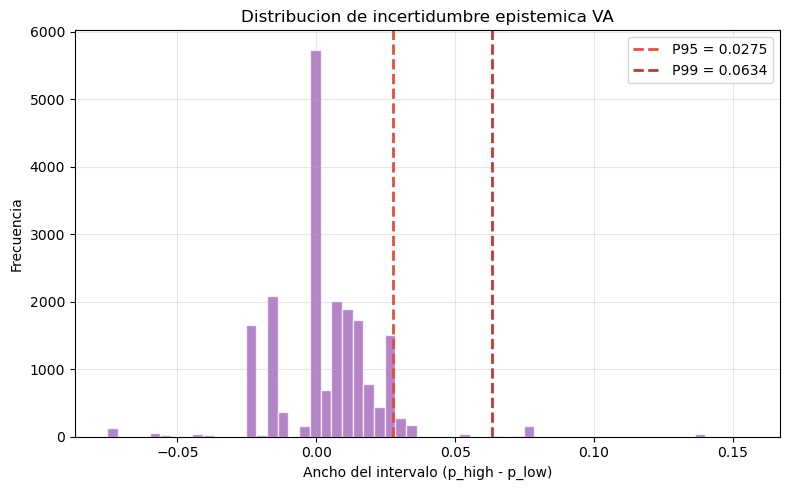

Estadisticas del ancho [p_high - p_low]:
  Min:     -0.0754
  Mediana: 0.0010
  Media:   0.0031
  P95:     0.0275
  P99:     0.0634
  Max:     0.1554

POLITICA DE DERIVACION BASADA EN ANCHO DEL INTERVALO VA
    Umbral (width > 0.2):
    Casos derivados:             0 (0.0%)
    Tasa default derivados:  0.0000  (base: 0.1998)
    Tasa default automatico: 0.1998
    Ratio riesgo derivados/auto: 0.00x

  Interpretacion: si los casos derivados concentran MAS defaults que la
  media, el ancho VA esta detectando incertidumbre epistemica genuina
  (no solo ruido) -> la derivacion a agente aporta valor de negocio.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score


# ---------------------------------------------------------------
# Venn-Abers: intervalos [p_low, p_high] y derivacion a agente humano
# ---------------------------------------------------------------
# VA no solo produce una probabilidad puntual q, tambien produce un
# intervalo [p_low, p_high]:
#   p_low  = P(y=1 | asumo y_test=0)
#   p_high = P(y=1 | asumo y_test=1)
# Siempre p_low <= p_high.
#
# El ancho (p_high - p_low) mide INCERTIDUMBRE EPISTEMICA:
#   - ancho pequeno -> VA esta seguro de la probabilidad
#   - ancho grande  -> VA no tiene datos suficientes en esa zona
#                      del score -> candidato a revision humana

# Extraer p0, p1 del VA ya fiteado (CVAP 10-fold)
# OJO: con CVAP (inductive=False) la libreria devuelve p0p1 como una LISTA
# de n_splits arrays (n_test, 2), uno por fold. Hay que consolidar.
# Con IVAP (inductive=True) devuelve directamente un array (n_test, 2).

_, p0p1 = va_cal.predict_proba(X_test_filtered, p0_p1_output=True)
p0p1 = np.asarray(p0p1)
if p0p1.ndim == 3:
    # CVAP: (n_splits, n_test, 2) -> promediar sobre folds
    print(f"CVAP detectado: consolidando {p0p1.shape[0]} folds por promedio")
    p_low  = p0p1[:, :, 0].mean(axis=0)
    p_high = p0p1[:, :, 1].mean(axis=0)
else:
    # IVAP: (n_test, 2)
    p_low  = p0p1[:, 0]
    p_high = p0p1[:, 1]

width = p_high - p_low


# ---  Distribucion del ancho del intervalo. HISTOGRAMA 
p95 = np.percentile(width, 95)
p99 = np.percentile(width, 99)

plt.figure(figsize=(8, 5))

plt.hist(width, bins=60, color='#9b59b6', alpha=0.75, edgecolor='white')
plt.axvline(p95, color='#e74c3c', ls='--', lw=2, label=f'P95 = {p95:.4f}')
plt.axvline(p99, color='#c0392b', ls='--', lw=2, label=f'P99 = {p99:.4f}')

plt.xlabel('Ancho del intervalo (p_high - p_low)')
plt.ylabel('Frecuencia')
plt.title('Distribucion de incertidumbre epistemica VA')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Estadisticas del ancho [p_high - p_low]:")
print(f"  Min:     {width.min():.4f}")
print(f"  Mediana: {np.median(width):.4f}")
print(f"  Media:   {width.mean():.4f}")
print(f"  P95:     {p95:.4f}")
print(f"  P99:     {p99:.4f}")
print(f"  Max:     {width.max():.4f}")


# ---  Politica de derivacion: valida si el ancho segmenta riesgo
print("\n" + "=" * 75)
print("POLITICA DE DERIVACION BASADA EN ANCHO DEL INTERVALO VA")
print("=" * 75)

# Tasa base de default en el test.
base_rate = y_test_flat.mean()

# Segmentar casos con ancho > umbral (candidatos a derivar a agente humano) Devuelve TRUE para los que derivamso a agente y FALSE para los que no.  
mask_agent = width > 0.2
mask_auto = ~mask_agent

n_agent = mask_agent.sum()
n_auto  = mask_auto.sum()


if n_agent > 0:
    dr_routed = y_test_flat[mask_agent].mean()
    dr_auto   = y_test_flat[~mask_agent].mean()
else: 
    dr_routed = 0.0 
    dr_auto   = y_test_flat[~mask_agent].mean()

pct_agent = n_agent / len(width) * 100

#Metricas solo sobre los casos derivados a agente humano

if n_auto > 0:
    y_auto = y_test_flat[mask_auto]
    probs_auto = probs_va[mask_auto]
    y_pred_auto = (probs_auto >= 0.5).astype(int)

    acc_auto = accuracy_score(y_auto, y_pred_auto)
    prec_auto = precision_score(y_auto, y_pred_auto, zero_division=0)
    rec_auto = recall_score(y_auto, y_pred_auto, zero_division=0)

else:
    print("\nNo hay casos auto-decididos")


print("\nMetricas solo sobre casos auto-decididos:")
print(f"Accuracy auto:  {acc_auto:.4f}")
print(f"Precision auto: {prec_auto:.4f}")
print(f"Recall auto:    {rec_auto:.4f}")


print(f"    Umbral (width > 0.2):")
print(f"    Casos derivados:         {n_agent:>5} ({pct_agent:.1f}%)")
print(f"    Tasa default derivados:  {dr_routed:.4f}  (base: {base_rate:.4f})")
print(f"    Tasa default automatico: {dr_auto:.4f}")
print(f"    Ratio riesgo derivados/auto: {dr_routed/dr_auto:.2f}x")

print("\n  Interpretacion: si los casos derivados concentran MAS defaults que la")
print("  media, el ancho VA esta detectando incertidumbre epistemica genuina")
print("  (no solo ruido) -> la derivacion a agente aporta valor de negocio.")




## Intrepretacion: 

Analizando las metricas pordemos concluir que los intervalos son muy estrechos en casi todo el conjunto del test. Por lo tanto, para la gran mayoría de clientes, Venn-Abers asigna probabilidades con muy poco incertidumbre. Incluso el máximo ancho observado (0.1554) sigue siendo menor a 0.2 que es el umbralq ue se ha fijado. Por lo tanto, todos los interavlos son lo sufucentemnete estrechos como para no ser desviados a ningun agente.

El propio metodo de Ven Abers actua como mecanismo de calibracion para los casos que permaneces en automatico (en este caso son todos). Por lo tanto no seria necesario añadir posteriormente una calibracion puntual adicional. 

Además, dado que no hemos derivado a agente humna ningun caso, las metricas de los casos auto-decididos coinciden con las métricas globales. 

